# Synthetic GelMA Hydrogel Subunit Protein Design (Waterloo iGEM 2025)

authors: Sydney Sherwood (sydney.sherwood@uwaterloo.ca), Curtis Yeung (curtis.yeung@uwaterloo.ca)

***dependencies***

In [5]:
import numpy as np
import glob
import os
import pandas as pd
from Bio import SeqIO
import re
import sys
sys.path.append('scripts/')
from AF2_HelperFunctions import *
import tqdm

-------------------------

### Generate Backbone Repeating GPH Motifs

sample `num_repeats` 6-10

this step was manually completed on AlphaFold3 WebServer. Outputs are present in `outputs`, in `.mmcif` format.

--------------------

### Generate MPNN redesigns of GXY motifs

sample mpnn command:

```
python ../ProteinMPNN/protein_mpnn_run.py 
        --pdb_path ../data/pdbs/fold_collagen_6_repeats_model_0.pdb 
        --jsonl_path ../data/jsonl_constraints/fold_collagen_6_repeats_model_0.jsonl 
        --num_seq_per_target 20 0
        --sampling_temp 0.40 
        --model_name v_48_020 
        --out_folder ../outputs/ 
        --path_to_model_weights ../ProteinMPNN/vanilla_model_weights
```

sample outputs (`.fasta` format):

```
>pdbs\fold_collagen_6_repeats_model_0, score=1.4718, global_score=1.4718, fixed_chains=[], designed_chains=['A'], model_name=v_48_020, git_hash=8907e6671bfbfc92303b5f79c4b5e6ce47cdef57, seed=258
GPHGPHGPHGPHGPHGPH
>T=0.15, sample=1, score=1.1256, global_score=1.1256, seq_recovery=0.4444
GITGRYGVYGDFGPYGPY
>T=0.15, sample=2, score=1.0813, global_score=1.0813, seq_recovery=0.4444
GITGRYGVYGDYGPYGPN
>T=0.15, sample=3, score=1.1482, global_score=1.1482, seq_recovery=0.5000
GFTGEHGVLGRYGPYGPY
>T=0.15, sample=4, score=1.1760, global_score=1.1760, seq_recovery=0.5556
GETGPFGRFGPYGPYGPY
>T=0.15, sample=5, score=1.0304, global_score=1.0304, seq_recovery=0.4444
GLTGENGIYGRNGPLGPN
>T=0.15, sample=6, score=1.0924, global_score=1.0924, seq_recovery=0.5000
GRTGLYGEYGPYGPLGPY
>T=0.15, sample=7, score=1.1424, global_score=1.1424, seq_recovery=0.3333
GETGVYGRYGDYGPYGRY
>T=0.15, sample=8, score=1.1247, global_score=1.1247, seq_recovery=0.5000
GRTGLYGEYGPYGPYGPY
```

-----------

### Analysis of MPNN Outputs

#### 1. Load in .fa files and generate AF Jobs. Store seqs to frame `subunit_seqs' w/ relevant data

In [3]:
mpnn_outputs = glob.glob("fas/*.fa")

In [8]:
def parse_mpnn_fastas(fasta_dir):
    records = []

    for fname in os.listdir(fasta_dir):
        if fname.endswith('.fa') or fname.endswith('.fasta'):
            model_name = os.path.splitext(fname)[0]
            path = os.path.join(fasta_dir, fname)
            for record in SeqIO.parse(path, "fasta"):
                meta = {
                    "model": model_name,
                    "sequence": str(record.seq),
                    "header": record.description
                }

                # Extract metadata from the FASTA header using regex
                meta["temperature"] = float(re.search(r'T=([\d.]+)', record.description).group(1)) if "T=" in record.description else None
                meta["sample"] = int(re.search(r'sample=(\d+)', record.description).group(1)) if "sample=" in record.description else None
                meta["score"] = float(re.search(r'score=([\d.]+)', record.description).group(1)) if "score=" in record.description else None
                meta["seq_recovery"] = float(re.search(r'seq_recovery=([\d.]+)', record.description).group(1)) if "seq_recovery=" in record.description else None

                records.append(meta)

    return pd.DataFrame(records)


In [9]:
subunit_seqs = parse_mpnn_fastas("fas")
subunit_seqs.head(2)

,model,sequence,header,temperature,sample,score,seq_recovery
0,fold_collagen_6_repeats_model_0,GPHGPHGPHGPHGPHGPH,"fold_collagen_6_repeats_model_0, score=2.6707,...",NaN,NaN,2.6707,NaN
1,fold_collagen_6_repeats_model_0,GAKGALGAIGAYGPKGPV,"T=0.45, sample=1, score=2.4946, global_score=1...",0.45,1.0,2.4946,0.1667


***write superfold commands. these were submitted to our cluster compute environment***

In [10]:
def WriteSuperfoldCommand(fa, outdir, ref=None, num_recycles=5, model=4, initial_guess=False):
    if (initial_guess and ref == None):
        raise ValueError('Need to provide reference pdb if intial_guess')
    cmd= f'''apptainer run --nv --bind /net:/net --bind /scratch:/scratch /net/software/containers/superfold.sif /net/software/superfold/run_superfold.py {fa} \
--models {model} \
--out_dir {outdir} \
--max_recycles {num_recycles} '''
    if ref != None:
        cmd += f'--reference {ref} '
    if initial_guess:
        cmd += f'--initial_guess {ref} '
    return cmd

In [14]:
import os

af2_folder = 'output/af2/'
os.makedirs(af2_folder, exist_ok=True)

# Initialize counters
design_ctr = 0
af2_cmds = []

# Loop through sequences and write AF2 input files
for i in range(len(subunit_seqs)):
    seq = subunit_seqs.loc[i, 'sequence']
    model_id = subunit_seqs.loc[i, 'model']

    # Numbered name (zero-padded)
    model_name = f"seq_{i+1:04d}_{model_id}"

    # Each model gets its own folder
    model_dir = os.path.join(af2_folder, model_name)
    os.makedirs(model_dir, exist_ok=True)

    # Write .fa file
    fasta_path = os.path.join(model_dir, f"{model_name}.fa")
    with open(fasta_path, 'w') as f:
        f.write(f">{model_name}\n{seq}\n")

    # Generate Superfold command
    af2_cmd = WriteSuperfoldCommand(fasta_path, model_dir)
    af2_cmds.append(af2_cmd)

    design_ctr += 1

# Write command list to task file
os.makedirs("tasks", exist_ok=True)
with open("tasks/igemfold.tasks", 'w') as f:
    for cmd in af2_cmds:
        f.write(cmd + '\n')

print(f'{design_ctr} AF2 tasks written')

1005 AF2 tasks written


submit `igemfold.tasks` to hpc

#### 2. read in AF2 metrics (outputs were copied over from cluster compute environment)

In [6]:
predictions = f'output/af2/'
all_preds = glob.glob(f"{predictions}*/*.json")
AF2_df = LoadAF2Metrics(all_preds)
AF2_df.to_csv('AF2_metrics_before_RMSD.csv')

AF2_df.head(2)

100%|██████████| 534/534 [00:00<00:00, 3264.90it/s]


,mean_plddt,recycles,tol,model,type,seed,mean_pae_interaction,mean_pae_intra_chain_A,mean_pae_intra_chain,mean_pae,pTMscore,elapsed_time,filepath,design,PDB
0,71.320999,5,0.116838,4,monomer_ptm,0,NaN,9.206048,9.206048,9.820905,0.023093,56.359487,output/af2/seq_0105_fold_collagen_6_repeats_mo...,seq_0105_fold_collagen_6_repeats_model_0,output/af2/seq_0105_fold_collagen_6_repeats_mo...
1,93.620186,5,0.090794,4,monomer_ptm,0,NaN,4.898059,4.898059,5.396614,0.107788,55.840561,output/af2/seq_0846_fold_collagen_7_repeats_mo...,seq_0846_fold_collagen_7_repeats_model_0,output/af2/seq_0846_fold_collagen_7_repeats_mo...


In [7]:
# Initialize the new columns with NaN values if they don't exist
if 'rmsd_to_reference' not in AF2_df.columns:
    AF2_df['rmsd_to_reference'] = float('nan')

ctr = 0 
for i, r in tqdm.tqdm(AF2_df.iterrows(), total=AF2_df.shape[0]):
    if pd.notna(r['rmsd_to_reference']):
        continue  
    parent_id = '_'.join(r['PDB'].split('/')[-1].split('_')[2:8]) 
  
    ref_pdb =f'input/parent/{parent_id}.pdb'
    rmsd = rmsd_kabsch(ref_pdb, r['PDB'], ['A']) # calculate ca-rmsd over chain A
    try:
        rmsd = rmsd_kabsch(ref_pdb, r['PDB'], ['A']) # calculate ca-rmsd over chain A
    except Exception as e:
        ctr += 1
    else:
        AF2_df.at[i, 'rmsd_to_reference'] = rmsd

# Save the updated DataFrame
AF2_df.to_csv('af2_metrics.csv')

AF2_df

100%|██████████| 534/534 [00:02<00:00, 222.21it/s]

0 designs (0%) had a problem in the alignment.


,mean_plddt,recycles,tol,model,type,seed,mean_pae_interaction,mean_pae_intra_chain_A,mean_pae_intra_chain,mean_pae,pTMscore,elapsed_time,filepath,design,PDB,rmsd_to_reference
0,71.320999,5,0.116838,4,monomer_ptm,0,NaN,9.206048,9.206048,9.820905,0.023093,56.359487,output/af2/seq_0105_fold_collagen_6_repeats_mo...,seq_0105_fold_collagen_6_repeats_model_0,output/af2/seq_0105_fold_collagen_6_repeats_mo...,8.487636
1,93.620186,5,0.090794,4,monomer_ptm,0,NaN,4.898059,4.898059,5.396614,0.107788,55.840561,output/af2/seq_0846_fold_collagen_7_repeats_mo...,seq_0846_fold_collagen_7_repeats_model_0,output/af2/seq_0846_fold_collagen_7_repeats_mo...,1.418316
2,58.371346,5,0.422294,4,monomer_ptm,0,NaN,14.897200,14.897200,15.225532,0.128275,56.260277,output/af2/seq_0575_fold_collagen_10_repeats_m...,seq_0575_fold_collagen_10_repeats_model_0,output/af2/seq_0575_fold_collagen_10_repeats_m...,4.975968
3,92.766510,5,0.032913,4,monomer_ptm,0,NaN,6.079587,6.079587,6.610748,0.187817,53.805704,output/af2/seq_0281_fold_collagen_8_repeats_mo...,seq_0281_fold_collagen_8_repeats_model_0,output/af2/seq_0281_fold_collagen_8_repeats_mo...,1.624115
4,88.182213,5,0.096622,4,monomer_ptm,0,NaN,8.119532,8.119532,8.532747,0.198013,55.907560,output/af2/seq_0634_fold_collagen_9_repeats_mo...,seq_0634_fold_collagen_9_repeats_model_0,output/af2/seq_0634_fold_collagen_9_repeats_mo...,1.667769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529,63.099827,5,0.653345,4,monomer_ptm,0,NaN,11.809704,11.809704,12.229551,0.183186,56.579846,output/af2/seq_0590_fold_collagen_10_repeats_m...,seq_0590_fold_collagen_10_repeats_model_0,output/af2/seq_0590_fold_collagen_10_repeats_m...,10.655527
530,73.286209,5,0.130200,4,monomer_ptm,0,NaN,7.520797,7.520797,8.114983,0.027845,55.860249,output/af2/seq_0014_fold_collagen_6_repeats_mo...,seq_0014_fold_collagen_6_repeats_model_0,output/af2/seq_0014_fold_collagen_6_repeats_mo...,6.230765
531,86.744568,5,0.208538,4,monomer_ptm,0,NaN,8.868863,8.868863,9.269479,0.196578,56.101239,output/af2/seq_0725_fold_collagen_9_repeats_mo...,seq_0725_fold_collagen_9_repeats_model_0,output/af2/seq_0725_fold_collagen_9_repeats_mo...,1.902378
532,93.473267,5,0.023881,4,monomer_ptm,0,NaN,6.019415,6.019415,6.547896,0.182947,53.653426,output/af2/seq_0342_fold_collagen_8_repeats_mo...,seq_0342_fold_collagen_8_repeats_model_0,output/af2/seq_0342_fold_collagen_8_repeats_mo...,1.537401


Index(['mean_plddt', 'recycles', 'tol', 'model', 'type', 'seed',
       'mean_pae_interaction', 'mean_pae_intra_chain_A',
       'mean_pae_intra_chain', 'mean_pae', 'pTMscore', 'elapsed_time',
       'filepath', 'design', 'PDB', 'rmsd_to_reference'],
      dtype='object')


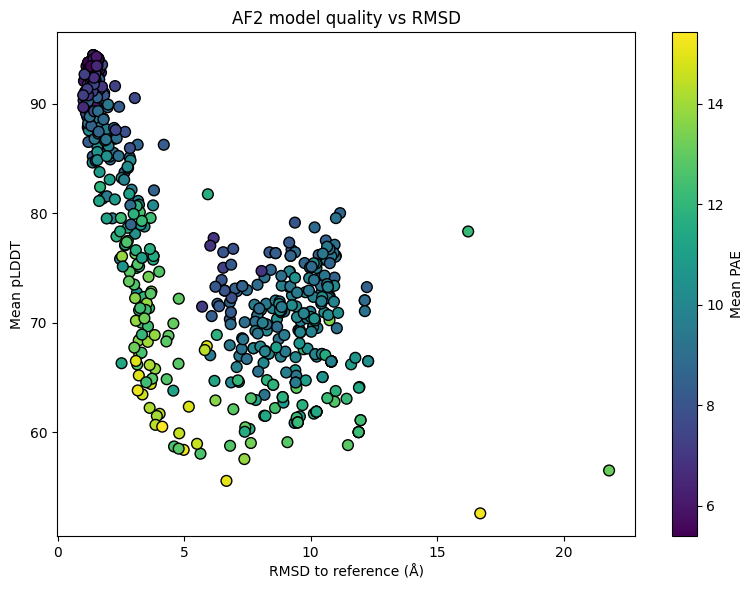

In [9]:
import matplotlib.pyplot as plt

# Quick check of columns
print(AF2_df.columns)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(AF2_df["rmsd_to_reference"], AF2_df["mean_plddt"],
            c=AF2_df["mean_pae"], cmap="viridis", s=60, edgecolor="k")

plt.xlabel("RMSD to reference (Å)")
plt.ylabel("Mean pLDDT")
cbar = plt.colorbar()
cbar.set_label("Mean PAE")

plt.title("AF2 model quality vs RMSD")
plt.tight_layout()
plt.show()

In [10]:
thr = {'rmsd': 5, 'pae': 10, 'plddt': 80}

passing_mask = (
    (AF2_df['rmsd_to_reference'] < thr['rmsd']) &
    (AF2_df['mean_pae'] < thr['pae']) &
    (AF2_df['mean_plddt'] > thr['plddt'])
)

AF2_pass = AF2_df[passing_mask].copy()

print(f"{len(AF2_pass)} / {len(AF2_df)} models pass all thresholds")
AF2_pass

157 / 534 models pass all thresholds


,mean_plddt,recycles,tol,model,type,seed,mean_pae_interaction,mean_pae_intra_chain_A,mean_pae_intra_chain,mean_pae,pTMscore,elapsed_time,filepath,design,PDB,rmsd_to_reference
1,93.620186,5,0.090794,4,monomer_ptm,0,NaN,4.898059,4.898059,5.396614,0.107788,55.840561,output/af2/seq_0846_fold_collagen_7_repeats_mo...,seq_0846_fold_collagen_7_repeats_model_0,output/af2/seq_0846_fold_collagen_7_repeats_mo...,1.418316
3,92.766510,5,0.032913,4,monomer_ptm,0,NaN,6.079587,6.079587,6.610748,0.187817,53.805704,output/af2/seq_0281_fold_collagen_8_repeats_mo...,seq_0281_fold_collagen_8_repeats_model_0,output/af2/seq_0281_fold_collagen_8_repeats_mo...,1.624115
4,88.182213,5,0.096622,4,monomer_ptm,0,NaN,8.119532,8.119532,8.532747,0.198013,55.907560,output/af2/seq_0634_fold_collagen_9_repeats_mo...,seq_0634_fold_collagen_9_repeats_model_0,output/af2/seq_0634_fold_collagen_9_repeats_mo...,1.667769
6,92.882805,5,0.037251,4,monomer_ptm,0,NaN,6.153602,6.153602,6.654061,0.174831,53.290407,output/af2/seq_0323_fold_collagen_8_repeats_mo...,seq_0323_fold_collagen_8_repeats_model_0,output/af2/seq_0323_fold_collagen_8_repeats_mo...,1.704562
11,92.101707,5,0.032396,4,monomer_ptm,0,NaN,6.396389,6.396389,6.900059,0.176790,53.451903,output/af2/seq_0204_fold_collagen_8_repeats_mo...,seq_0204_fold_collagen_8_repeats_model_0,output/af2/seq_0204_fold_collagen_8_repeats_mo...,1.102426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,89.700798,5,0.027535,4,monomer_ptm,0,NaN,6.062644,6.062644,6.582726,0.100720,55.984007,output/af2/seq_0832_fold_collagen_7_repeats_mo...,seq_0832_fold_collagen_7_repeats_model_0,output/af2/seq_0832_fold_collagen_7_repeats_mo...,1.005664
522,90.799866,5,0.076888,4,monomer_ptm,0,NaN,6.757912,6.757912,7.240041,0.174198,53.389350,output/af2/seq_0265_fold_collagen_8_repeats_mo...,seq_0265_fold_collagen_8_repeats_model_0,output/af2/seq_0265_fold_collagen_8_repeats_mo...,1.000811
527,93.455696,5,0.078321,4,monomer_ptm,0,NaN,4.903219,4.903219,5.444270,0.111848,56.082336,output/af2/seq_0827_fold_collagen_7_repeats_mo...,seq_0827_fold_collagen_7_repeats_model_0,output/af2/seq_0827_fold_collagen_7_repeats_mo...,1.306570
531,86.744568,5,0.208538,4,monomer_ptm,0,NaN,8.868863,8.868863,9.269479,0.196578,56.101239,output/af2/seq_0725_fold_collagen_9_repeats_mo...,seq_0725_fold_collagen_9_repeats_model_0,output/af2/seq_0725_fold_collagen_9_repeats_mo...,1.902378


In [11]:
import os, shutil

# directory for passing models
out_dir = "AF2_passing"
os.makedirs(out_dir, exist_ok=True)

for _, row in AF2_pass.iterrows():
    src = row["PDB"]   
    dst = os.path.join(out_dir, os.path.basename(src))
    shutil.copy(src, dst)

print(f"Copied {len(AF2_pass)} passing models into {out_dir}/")

Copied 157 passing models into AF2_passing/


In [12]:
import os
import subprocess
from pathlib import Path

HELIX_SCRIPT = "make_trihelix_simple.py"   
OUT_DIR = "trihelix_out_pass"            

RADIUS = 4.6
RISE = 2.86
STAGGER_RES = 1
ANGLES = (0, 120, 240)

# --------------------------------
os.makedirs(OUT_DIR, exist_ok=True)

if not Path(HELIX_SCRIPT).exists():
    raise FileNotFoundError(f"Could not find {HELIX_SCRIPT}. Set HELIX_SCRIPT to the correct path.")

ok, fail = 0, []
for i, row in AF2_pass.iterrows():
    in_pdb = Path(row["PDB"])
    if not in_pdb.exists():
        fail.append((str(in_pdb), "missing input pdb"))
        continue

    out_name = f"{in_pdb.stem}_trihelix.pdb"
    out_pdb = Path(OUT_DIR) / out_name

    cmd = [
        "python3", HELIX_SCRIPT,
        "--in_pdb", str(in_pdb),
        "--out_pdb", str(out_pdb),
        "--radius", str(RADIUS),
        "--rise", str(RISE),
        "--stagger_res", str(STAGGER_RES),
        "--angles", str(ANGLES[0]), str(ANGLES[1]), str(ANGLES[2]),
    ]

    try:
        cp = subprocess.run(cmd, check=True, capture_output=True, text=True)
        print(cp.stdout.strip() or f"[ok] wrote {out_pdb}")
        ok += 1
    except subprocess.CalledProcessError as e:
        print(f"[fail] {in_pdb} -> {out_pdb}\n{e.stderr}")
        fail.append((str(in_pdb), e.stderr.strip() if e.stderr else "unknown error"))

print(f"\nDone. Built {ok} tri-helices into {OUT_DIR}/")
if fail:
    print("Failures:")
    for f in fail:
        print(" -", f[0], ":", f[1])

[ok] wrote trihelix_out_pass/seq_0846_fold_collagen_7_repeats_model_0_model_4_ptm_seed_0_unrelaxed_trihelix.pdb  (radius=4.60 Å, stagger=1.0×2.86 Å, angles=[0.0, 120.0, 240.0])
[ok] wrote trihelix_out_pass/seq_0281_fold_collagen_8_repeats_model_0_model_4_ptm_seed_0_unrelaxed_trihelix.pdb  (radius=4.60 Å, stagger=1.0×2.86 Å, angles=[0.0, 120.0, 240.0])
[ok] wrote trihelix_out_pass/seq_0634_fold_collagen_9_repeats_model_0_model_4_ptm_seed_0_unrelaxed_trihelix.pdb  (radius=4.60 Å, stagger=1.0×2.86 Å, angles=[0.0, 120.0, 240.0])
[ok] wrote trihelix_out_pass/seq_0323_fold_collagen_8_repeats_model_0_model_4_ptm_seed_0_unrelaxed_trihelix.pdb  (radius=4.60 Å, stagger=1.0×2.86 Å, angles=[0.0, 120.0, 240.0])
[ok] wrote trihelix_out_pass/seq_0204_fold_collagen_8_repeats_model_0_model_4_ptm_seed_0_unrelaxed_trihelix.pdb  (radius=4.60 Å, stagger=1.0×2.86 Å, angles=[0.0, 120.0, 240.0])
[ok] wrote trihelix_out_pass/seq_0811_fold_collagen_7_repeats_model_0_model_4_ptm_seed_0_unrelaxed_trihelix.pdb  (r

we then assembled these into tri-helices using `make_trihelix_simple.py`

----------

### Analysis of Methacrylation Sites and Cleavage Sites

In [13]:
from pathlib import Path
import analyze_trihelix_metrics as atm
import pandas as pd

tri_dir = "trihelix_out_pass"

results = []
for pdb in Path(tri_dir).glob("*.pdb"):
    res = atm.analyze_one(pdb)  
    results.append(res)

AF2_metrics = pd.DataFrame(results)
AF2_metrics

,model,pdb_path,length,num_K,exposed_K,DOM_per100,CLS_pairs,CLS_per100,DP_sites,DP_per100,mean_SASA_res
0,seq_0507_fold_collagen_10_repeats_model_0_mode...,trihelix_out_pass/seq_0507_fold_collagen_10_re...,90,15,12,13.333,9,10.000,1,1.111,0.86
1,seq_0634_fold_collagen_9_repeats_model_0_model...,trihelix_out_pass/seq_0634_fold_collagen_9_rep...,81,9,7,8.642,5,6.173,2,2.469,0.85
2,seq_0828_fold_collagen_7_repeats_model_0_model...,trihelix_out_pass/seq_0828_fold_collagen_7_rep...,63,6,5,7.937,4,6.349,0,0.000,0.89
3,seq_0736_fold_collagen_9_repeats_model_0_model...,trihelix_out_pass/seq_0736_fold_collagen_9_rep...,81,9,8,9.877,7,8.642,0,0.000,0.86
4,seq_0282_fold_collagen_8_repeats_model_0_model...,trihelix_out_pass/seq_0282_fold_collagen_8_rep...,72,9,7,9.722,5,6.944,0,0.000,0.91
...,...,...,...,...,...,...,...,...,...,...,...
152,seq_0270_fold_collagen_8_repeats_model_0_model...,trihelix_out_pass/seq_0270_fold_collagen_8_rep...,72,9,6,8.333,3,4.167,0,0.000,0.87
153,seq_0586_fold_collagen_10_repeats_model_0_mode...,trihelix_out_pass/seq_0586_fold_collagen_10_re...,90,9,7,7.778,5,5.556,0,0.000,0.85
154,seq_0248_fold_collagen_8_repeats_model_0_model...,trihelix_out_pass/seq_0248_fold_collagen_8_rep...,72,6,5,6.944,4,5.556,0,0.000,0.89
155,seq_0616_fold_collagen_9_repeats_model_0_model...,trihelix_out_pass/seq_0616_fold_collagen_9_rep...,81,9,8,9.877,7,8.642,0,0.000,0.89


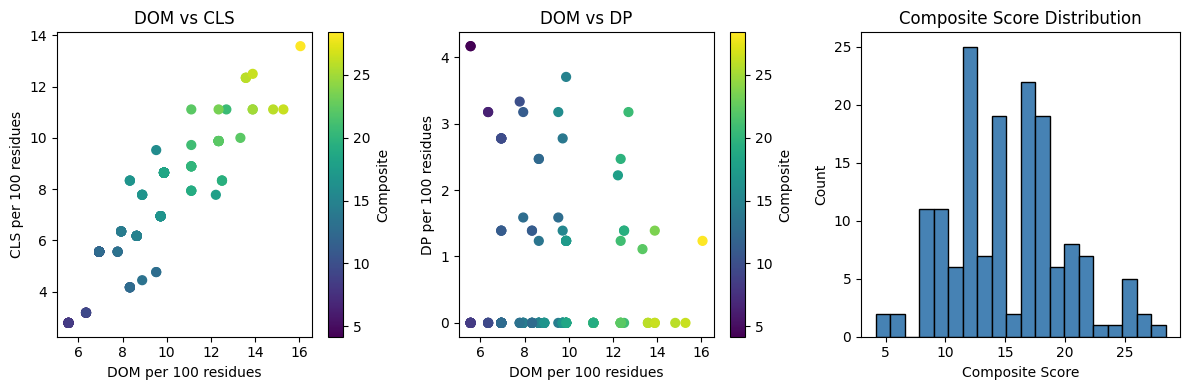

,Type,model,DOM_per100,CLS_per100,DP_per100,Composite
0,Rigid,seq_0709_fold_collagen_9_repeats_model_0_model...,16.049,13.580,1.235,28.394
1,Degradable,seq_0225_fold_collagen_8_repeats_model_0_model...,5.556,2.778,4.167,4.167
2,Balanced,seq_0734_fold_collagen_9_repeats_model_0_model...,8.642,6.173,0.000,14.815


In [14]:
import matplotlib.pyplot as plt

# Composite score (high DOM + CLS, low DP is better)
AF2_metrics["Composite"] = (
    AF2_metrics["DOM_per100"] + AF2_metrics["CLS_per100"] - AF2_metrics["DP_per100"]
)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(AF2_metrics["DOM_per100"], AF2_metrics["CLS_per100"],
            c=AF2_metrics["Composite"], cmap="viridis", s=40)
plt.colorbar(label="Composite")
plt.xlabel("DOM per 100 residues")
plt.ylabel("CLS per 100 residues")
plt.title("DOM vs CLS")

plt.subplot(1,3,2)
plt.scatter(AF2_metrics["DOM_per100"], AF2_metrics["DP_per100"],
            c=AF2_metrics["Composite"], cmap="viridis", s=40)
plt.colorbar(label="Composite")
plt.xlabel("DOM per 100 residues")
plt.ylabel("DP per 100 residues")
plt.title("DOM vs DP")

plt.subplot(1,3,3)
plt.hist(AF2_metrics["Composite"], bins=20, color="steelblue", edgecolor="black")
plt.xlabel("Composite Score")
plt.ylabel("Count")
plt.title("Composite Score Distribution")

plt.tight_layout()
plt.show()

rigid = AF2_metrics.sort_values("Composite", ascending=False).iloc[0]
degradable = AF2_metrics.sort_values("DP_per100", ascending=False).iloc[0]
median_val = AF2_metrics["Composite"].median()
balanced = AF2_metrics.iloc[(AF2_metrics["Composite"]-median_val).abs().argsort().iloc[0]]

exemplars = pd.DataFrame([
    {"Type":"Rigid", **rigid[["model","DOM_per100","CLS_per100","DP_per100","Composite"]]},
    {"Type":"Degradable", **degradable[["model","DOM_per100","CLS_per100","DP_per100","Composite"]]},
    {"Type":"Balanced", **balanced[["model","DOM_per100","CLS_per100","DP_per100","Composite"]]},
])
exemplars